# Branchability Diagnostic

Diagnostic for exact-prefix branch signal in Othello sequence chunks, used to decide whether Branch-Conditioned Dynamics JEPA is viable.

Fairness constraints:
- Uses only move sequences.
- Does not compute board states.
- Does not query legal moves.
- Does not replay games or import objective/training modules.


## 1. Mount Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Configure Paths And Diagnostic Knobs


In [2]:
from pathlib import Path
import os
import subprocess
import sys

PROJECT_ROOT = Path('/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code')
ARTIFACT_ROOT = Path('/content/drive/MyDrive/Master_Thesis_Artifacts')
DATA_ROOT = ARTIFACT_ROOT / 'data'
RUNS_DIR = ARTIFACT_ROOT / 'runs'

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert (PROJECT_ROOT / 'pyproject.toml').exists(), PROJECT_ROOT
assert DATA_ROOT.exists(), DATA_ROOT
assert RUNS_DIR.exists(), RUNS_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(PROJECT_ROOT)], check=True)
os.chdir(PROJECT_ROOT)

BOARD_SIZE = 8
DATA_DIR = DATA_ROOT / f'othello_{BOARD_SIZE}x{BOARD_SIZE}'

MAX_CHUNKS = 20
T_MIN = 1
T_MAX = 20

OUT_DIR = RUNS_DIR / 'branchability'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / f'branchability_{MAX_CHUNKS}chunks.csv'
OUT_JSON = OUT_DIR / f'branchability_{MAX_CHUNKS}chunks.json'
OUT_PLOT = OUT_DIR / f'branchability_{MAX_CHUNKS}chunks.png'

PAD_TOKEN = BOARD_SIZE ** 2 - 4

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR    :', DATA_DIR)
print('OUT_DIR     :', OUT_DIR)
print('MAX_CHUNKS  :', MAX_CHUNKS)
print('T range     :', T_MIN, '..', T_MAX)
print('PAD_TOKEN   :', PAD_TOKEN)
assert DATA_DIR.exists(), DATA_DIR


PROJECT_ROOT: /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code
DATA_DIR    : /content/drive/MyDrive/Master_Thesis_Artifacts/data/othello_8x8
OUT_DIR     : /content/drive/MyDrive/Master_Thesis_Artifacts/runs/branchability
MAX_CHUNKS  : 20
T range     : 1 .. 20
PAD_TOKEN   : 60


## 3. Imports


In [3]:
import csv
import json
import math
from collections import Counter
from pathlib import Path

from othello_research.datasets.dataset import load_chunk

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

print('imports OK')


imports OK


## 4. Token-Sequence Helpers

`load_chunk` returns project games as raw board-cell move IDs. For this diagnostic we convert those IDs to the project's compact move-token vocabulary using a static mapping that excludes the four initial center cells. This is not board replay and does not use Othello rules or legal-move labels.


In [4]:
CSV_COLUMNS = [
    't',
    'n_samples',
    'n_unique_prefixes',
    'n_repeated_prefixes',
    'n_branchable_prefixes',
    'samples_in_branchable_prefixes',
    'branchable_sample_coverage',
    'mean_branch_factor',
    'max_branch_factor',
    'mean_samples_per_branchable_prefix',
    'mean_branch_entropy',
    'mean_branch_entropy_ratio',
]

TOP_PREFIX_T_VALUES = {1, 3, 5, 8, 10, 15, 20}

def build_raw_to_token(board_size: int) -> dict[int, int]:
    if board_size < 4 or board_size % 2:
        raise ValueError(f'board_size must be even and >= 4, got {board_size}')
    centers = {
        (board_size // 2 - 1) * board_size + (board_size // 2 - 1),
        (board_size // 2 - 1) * board_size + (board_size // 2),
        (board_size // 2) * board_size + (board_size // 2 - 1),
        (board_size // 2) * board_size + (board_size // 2),
    }
    mapping = {}
    token = 0
    for raw in range(board_size * board_size):
        if raw in centers:
            continue
        mapping[raw] = token
        token += 1
    return mapping

def first_pad_index(game, pad_token: int) -> int:
    for i, token in enumerate(game):
        if int(token) == pad_token:
            return i
    return i + 1 if 'i' in locals() else 0

def compact_prefix_and_action(game, t: int, raw_to_token: dict[int, int], pad_token: int):
    if len(game) <= t:
        return None
    tokens = []
    for raw_move in game[: t + 1]:
        token = raw_to_token.get(int(raw_move))
        if token is None:
            return None
        tokens.append(token)
    if first_pad_index(tokens, pad_token) <= t:
        return None
    return tuple(tokens[:t]), tokens[t]


## 5. Metric Helpers


In [5]:
def entropy_bits(counter: Counter) -> float:
    total = sum(counter.values())
    if total <= 0:
        return 0.0
    entropy = 0.0
    for count in counter.values():
        if count <= 0:
            continue
        p = count / total
        entropy -= p * math.log2(p)
    return entropy

def branch_entry_metrics(count: int, actions: Counter) -> dict:
    branch_factor = len(actions)
    entropy = entropy_bits(actions)
    entropy_ratio = entropy / math.log2(branch_factor) if branch_factor > 1 else 0.0
    return {
        'count': int(count),
        'branch_factor': int(branch_factor),
        'entropy': float(entropy),
        'entropy_ratio': float(entropy_ratio),
    }

def mean(values) -> float:
    return float(sum(values) / len(values)) if values else 0.0


## 6. Analyze One Prefix Length

This cell is memory-conscious: `prefix_stats` is built for one `t` only, then freed before the next `t`.


In [6]:
def analyze_t(t: int, chunks: list[Path], raw_to_token: dict[int, int], pad_token: int):
    prefix_stats = {}
    n_samples = 0
    games_processed = 0

    for chunk_path in chunks:
        games = load_chunk(str(chunk_path))
        games_processed += len(games)
        for game in games:
            sample = compact_prefix_and_action(game, t, raw_to_token, pad_token)
            if sample is None:
                continue
            prefix, next_action = sample
            entry = prefix_stats.get(prefix)
            if entry is None:
                entry = [0, Counter()]
                prefix_stats[prefix] = entry
            entry[0] += 1
            entry[1][int(next_action)] += 1
            n_samples += 1

    n_repeated_prefixes = 0
    n_branchable_prefixes = 0
    samples_in_branchable_prefixes = 0
    branch_factors = []
    branch_counts = []
    entropies = []
    entropy_ratios = []
    top_candidates = []

    for prefix, (count, actions) in prefix_stats.items():
        if count >= 2:
            n_repeated_prefixes += 1
        if len(actions) >= 2:
            n_branchable_prefixes += 1
            samples_in_branchable_prefixes += count
            metrics = branch_entry_metrics(count, actions)
            branch_factors.append(metrics['branch_factor'])
            branch_counts.append(count)
            entropies.append(metrics['entropy'])
            entropy_ratios.append(metrics['entropy_ratio'])
            top_candidates.append((prefix, count, actions))

    row = {
        't': int(t),
        'n_samples': int(n_samples),
        'n_unique_prefixes': int(len(prefix_stats)),
        'n_repeated_prefixes': int(n_repeated_prefixes),
        'n_branchable_prefixes': int(n_branchable_prefixes),
        'samples_in_branchable_prefixes': int(samples_in_branchable_prefixes),
        'branchable_sample_coverage': float(samples_in_branchable_prefixes / n_samples) if n_samples else 0.0,
        'mean_branch_factor': mean(branch_factors),
        'max_branch_factor': int(max(branch_factors)) if branch_factors else 0,
        'mean_samples_per_branchable_prefix': mean(branch_counts),
        'mean_branch_entropy': mean(entropies),
        'mean_branch_entropy_ratio': mean(entropy_ratios),
    }

    top_prefixes = []
    for prefix, count, actions in sorted(top_candidates, key=lambda item: (-item[1], item[0]))[:10]:
        metrics = branch_entry_metrics(count, actions)
        top_prefixes.append({
            'prefix': list(prefix),
            'count': int(count),
            'branch_factor': int(metrics['branch_factor']),
            'entropy': float(metrics['entropy']),
            'entropy_ratio': float(metrics['entropy_ratio']),
            'action_counts': {str(action): int(action_count) for action, action_count in sorted(actions.items())},
        })

    del prefix_stats
    return row, top_prefixes, games_processed


## 7. Output Helpers


In [7]:
def write_csv(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        writer.writeheader()
        for row in rows:
            writer.writerow({key: row[key] for key in CSV_COLUMNS})

def write_json(path: Path, *, config: dict, rows: list[dict], top_prefixes: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        'config': config,
        'summary_table': rows,
        'top_branchable_prefixes_per_t': top_prefixes,
    }
    path.write_text(json.dumps(payload, indent=2), encoding='utf-8')

def save_plot(path: Path, rows: list[dict], data_dir: Path, n_chunks: int) -> None:
    if plt is None:
        print('matplotlib unavailable; skipping plot')
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    t_values = [int(row['t']) for row in rows]
    coverage = [float(row['branchable_sample_coverage']) for row in rows]
    branch_factor = [float(row['mean_branch_factor']) for row in rows]
    entropy = [float(row['mean_branch_entropy']) for row in rows]
    entropy_ratio = [float(row['mean_branch_entropy_ratio']) for row in rows]

    fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)
    fig.suptitle(f'Branchability: {data_dir.name} ({n_chunks} chunks)')

    axes[0].plot(t_values, coverage, marker='o')
    axes[0].set_ylabel('branchable coverage')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.3)

    line_factor = axes[1].plot(t_values, branch_factor, marker='o', color='tab:blue', label='mean branch factor')
    axes[1].set_ylabel('mean branch factor', color='tab:blue')
    axes[1].tick_params(axis='y', labelcolor='tab:blue')
    axes[1].grid(True, alpha=0.3)
    ax_entropy = axes[1].twinx()
    line_entropy = ax_entropy.plot(t_values, entropy, marker='s', color='tab:orange', label='mean entropy')
    ax_entropy.set_ylabel('mean entropy (bits)', color='tab:orange')
    ax_entropy.tick_params(axis='y', labelcolor='tab:orange')
    lines = line_factor + line_entropy
    axes[1].legend(lines, [line.get_label() for line in lines], loc='best')

    axes[2].plot(t_values, entropy_ratio, marker='o', color='tab:green')
    axes[2].set_ylabel('entropy ratio')
    axes[2].set_xlabel('prefix length t')
    axes[2].set_ylim(0.0, 1.0)
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()


## 8. Stdout Table And Interpretation


In [8]:
def print_table_header() -> None:
    print(
        f"{'t':>3s} {'samples':>12s} {'unique':>12s} {'repeat':>10s} "
        f"{'branch':>10s} {'coverage':>10s} {'bf':>7s} {'entropy':>9s} {'ratio':>8s}"
    )
    print('-' * 91)

def print_table_row(row: dict) -> None:
    print(
        f"{int(row['t']):3d} "
        f"{int(row['n_samples']):12,d} "
        f"{int(row['n_unique_prefixes']):12,d} "
        f"{int(row['n_repeated_prefixes']):10,d} "
        f"{int(row['n_branchable_prefixes']):10,d} "
        f"{float(row['branchable_sample_coverage']):10.4f} "
        f"{float(row['mean_branch_factor']):7.2f} "
        f"{float(row['mean_branch_entropy']):9.3f} "
        f"{float(row['mean_branch_entropy_ratio']):8.3f}"
    )

def interpretation(rows: list[dict]) -> str:
    row = min(rows, key=lambda item: abs(int(item['t']) - 8))
    t = int(row['t'])
    coverage = float(row['branchable_sample_coverage'])
    ratio = float(row['mean_branch_entropy_ratio'])

    if coverage > 0.30:
        coverage_case = '> 0.30  -> Exact-prefix Branch-Dynamics JEPA viable across the game.'
    elif coverage >= 0.10:
        coverage_case = (
            '0.10 to 0.30 -> Will be early-game biased. Consider combining with\n'
            '                 same-suffix hard negatives for late-game samples.'
        )
    else:
        coverage_case = (
            '< 0.10  -> Exact-prefix branching too sparse. Use exact-prefix\n'
            '           positives where available, plus same-suffix hard negatives\n'
            '           (never as positives).'
        )

    if ratio > 0.70:
        ratio_case = '> 0.7   -> Branching is balanced; raw coverage reflects usable signal.'
    elif ratio >= 0.40:
        ratio_case = (
            '0.4-0.7 -> Branching is moderately imbalanced; usable signal is lower\n'
            '           than coverage suggests.'
        )
    else:
        ratio_case = (
            '< 0.4   -> Branching is heavily dominated by one action per prefix;\n'
            '           despite coverage numbers, effective signal is weak.'
        )

    return f'''INTERPRETATION
==============

Coverage analysis at t={t}:
  branchable_sample_coverage = {coverage:.4f}

  {coverage_case}

Branch quality analysis at t={t}:
  mean_branch_entropy_ratio = {ratio:.4f}

  {ratio_case}

Combined verdict:
  Apply both criteria. High coverage with low entropy_ratio means the
  raw counts overestimate the actual learning signal available.
'''


## 9. Run Diagnostic


data_dir       : /content/drive/MyDrive/Master_Thesis_Artifacts/data/othello_8x8
chunks         : 20
t range        : 1..20
board_size     : 8
pad_token      : 60
  t      samples       unique     repeat     branch   coverage      bf   entropy    ratio
-------------------------------------------------------------------------------------------
  1    1,999,981            4          4          4     1.0000    3.00     1.585    1.000
  2    1,999,981           12         12         12     1.0000    4.67     2.215    1.000
  3    1,999,981           56         56         56     1.0000    4.36     2.057    1.000
  4    1,999,981          244        244        244     1.0000    5.72     2.480    1.000
  5    1,999,981        1,396      1,396      1,392     0.9966    5.89     2.501    0.999
  6    1,999,981        8,200      8,200      8,200     1.0000    6.72     2.683    0.993
  7    1,999,981       55,092     55,092     55,088     0.9999    6.79     2.590    0.955
  8    1,999,981      374

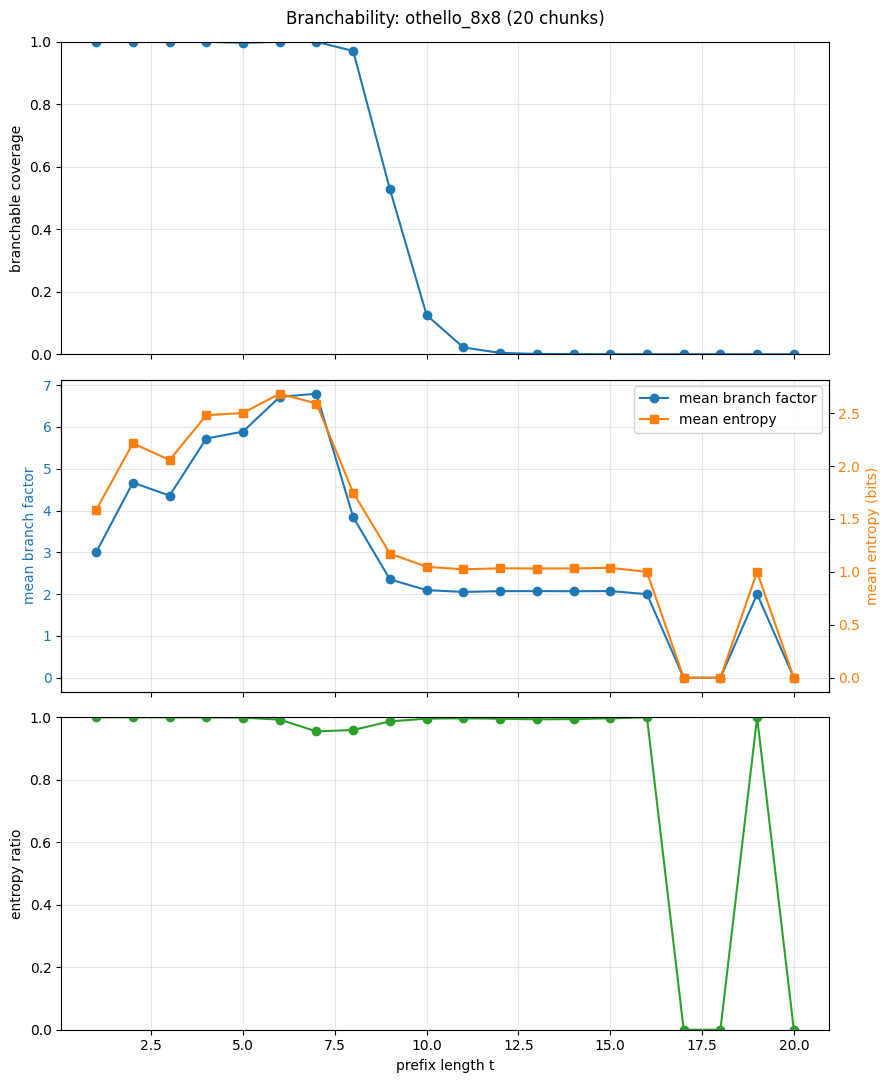

saved csv : /content/drive/MyDrive/Master_Thesis_Artifacts/runs/branchability/branchability_20chunks.csv
saved json: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/branchability/branchability_20chunks.json
saved plot: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/branchability/branchability_20chunks.png

INTERPRETATION

Coverage analysis at t=8:
  branchable_sample_coverage = 0.9705

  > 0.30  -> Exact-prefix Branch-Dynamics JEPA viable across the game.

Branch quality analysis at t=8:
  mean_branch_entropy_ratio = 0.9594

  > 0.7   -> Branching is balanced; raw coverage reflects usable signal.

Combined verdict:
  Apply both criteria. High coverage with low entropy_ratio means the
  raw counts overestimate the actual learning signal available.



In [9]:
if T_MIN < 0 or T_MAX < T_MIN:
    raise ValueError(f'Invalid t range: {T_MIN}..{T_MAX}')

chunks = sorted(DATA_DIR.glob('*.pickle'))[:MAX_CHUNKS]
if not chunks:
    raise FileNotFoundError(f'No .pickle chunks found in {DATA_DIR}')

n_t = T_MAX - T_MIN + 1
if MAX_CHUNKS > 50:
    print(
        f'WARNING: Processing all {len(chunks)} chunks with t_min={T_MIN}, t_max={T_MAX} means\n'
        f'{len(chunks)} * {n_t} = {len(chunks) * n_t} chunk reads. This will take a long time. Initial\n'
        'diagnostic recommendation: MAX_CHUNKS = 20.'
    )

raw_to_token = build_raw_to_token(BOARD_SIZE)

print(f'data_dir       : {DATA_DIR}')
print(f'chunks         : {len(chunks)}')
print(f't range        : {T_MIN}..{T_MAX}')
print(f'board_size     : {BOARD_SIZE}')
print(f'pad_token      : {PAD_TOKEN}')
print_table_header()

rows = []
top_prefixes = {}
total_games_processed = 0

for t in range(T_MIN, T_MAX + 1):
    row, top, games_processed = analyze_t(t, chunks, raw_to_token, PAD_TOKEN)
    total_games_processed = max(total_games_processed, games_processed)
    rows.append(row)
    if t in TOP_PREFIX_T_VALUES:
        top_prefixes[str(t)] = top
    print_table_row(row)

config = {
    'data_dir': str(DATA_DIR),
    'max_chunks': MAX_CHUNKS,
    't_min': T_MIN,
    't_max': T_MAX,
    'board_size': BOARD_SIZE,
    'pad_token': PAD_TOKEN,
    'chunks_processed': len(chunks),
    'total_games_processed': total_games_processed,
}

write_csv(OUT_CSV, rows)
write_json(OUT_JSON, config=config, rows=rows, top_prefixes=top_prefixes)
save_plot(OUT_PLOT, rows, DATA_DIR, len(chunks))

print('saved csv :', OUT_CSV)
print('saved json:', OUT_JSON)
print('saved plot:', OUT_PLOT)
print()
print(interpretation(rows))


## 10. Inspect Top Branchable Prefixes


In [10]:
for t_key, prefixes in top_prefixes.items():
    print(f'\nTop branchable prefixes for t={t_key}')
    for item in prefixes[:5]:
        print(
            f"count={item['count']:,} branch_factor={item['branch_factor']} "
            f"entropy={item['entropy']:.3f} ratio={item['entropy_ratio']:.3f} "
            f"prefix={item['prefix']} actions={item['action_counts']}"
        )



Top branchable prefixes for t=1
count=500,862 branch_factor=3 entropy=1.585 ratio=1.000 prefix=[40] actions={'27': 167038, '39': 166675, '41': 167149}
count=500,486 branch_factor=3 entropy=1.585 ratio=1.000 prefix=[26] actions={'18': 166606, '20': 166748, '32': 167132}
count=500,039 branch_factor=3 entropy=1.585 ratio=1.000 prefix=[33] actions={'27': 166535, '39': 166735, '41': 166769}
count=498,594 branch_factor=3 entropy=1.585 ratio=1.000 prefix=[19] actions={'18': 166395, '20': 165881, '32': 166318}

Top branchable prefixes for t=3
count=42,024 branch_factor=6 entropy=2.585 ratio=1.000 prefix=[40, 41, 42] actions={'20': 6965, '27': 6988, '32': 6999, '39': 7022, '48': 7038, '50': 7012}
count=41,986 branch_factor=5 entropy=2.322 ratio=1.000 prefix=[26, 18, 33] actions={'25': 8407, '27': 8449, '32': 8313, '39': 8436, '41': 8381}
count=41,904 branch_factor=5 entropy=2.322 ratio=1.000 prefix=[33, 41, 26] actions={'18': 8340, '20': 8447, '27': 8209, '32': 8472, '34': 8436}
count=41,773 b